Nombre: David Díaz Paz y Puente | Matrícula: 650794

# A2.3 Modelos de ensamble, SVM y redes neuronales

---

## Introducción

En esta actividad se analiza el comportamiento de distintos modelos avanzados de clasificación sobre el mismo conjunto de datos utilizado en actividades previas. En particular, se entrenan y comparan modelos basados en ensambles, márgenes máximos y redes neuronales, con el propósito de diagnosticar el estrato socioconómico de una familia dadas sus condiciones de vivienda como _Bajo_ (1), _Medio bajo_ (2), _Medio alto_ (3) y _Alto_ (4). 

Los modelos considerados en este reporte son Random Forest, Boosting, Support Vector Machine (SVM) y una red neuronal sencilla. La intención no es realizar una optimización exhaustiva de hiperparámetros, sino construir modelos razonables, evaluar su desempeño con métricas de clasificación y reflexionar sobre sus diferencias en términos de precisión, estabilidad, interpretabilidad y complejidad.

El análisis se desarrolla de forma que el lector pueda comprender la metodología, los resultados y las conclusiones sin necesidad de revisar el código fuente. Por ello, se presentan explicaciones en texto, tablas y figuras comparativas que permiten interpretar el comportamiento de cada modelo de manera clara.

---

## Preparación del escenario experimental

### Carga de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings('ignore')

### Carga del dataset

In [2]:
df = pd.read_csv(f"features_lasso.csv")
df.head()

,cocina,cocina_dor,num_cuarto,bano_comp,bano_excus,bano_regad,estim_pago,tot_resid,tipo_viv_4,mat_pared_7,...,eli_basura_4,eli_basura_5,eli_basura_6,tenencia_2,tenencia_4,tenencia_5,escrituras_4,escrituras_5,prop_muj,est_socio
0,1,2.0,4,1,0,0,3000.0,2,False,False,...,False,False,False,False,True,False,False,False,0.50,2
1,1,2.0,4,1,0,0,2500.0,4,False,False,...,False,False,False,False,False,False,False,True,0.75,2
2,1,2.0,5,2,0,0,3000.0,4,False,False,...,False,False,False,False,True,False,False,False,0.75,2
3,1,2.0,3,1,0,0,3000.0,2,False,False,...,False,False,False,False,True,False,False,False,0.50,2
4,1,2.0,4,1,0,0,2500.0,6,False,True,...,False,False,False,False,False,False,False,True,0.50,2


### Descripción del dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3767 entries, 0 to 3766
Data columns (total 45 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cocina        3767 non-null   int64  
 1   cocina_dor    3767 non-null   float64
 2   num_cuarto    3767 non-null   int64  
 3   bano_comp     3767 non-null   int64  
 4   bano_excus    3767 non-null   int64  
 5   bano_regad    3767 non-null   int64  
 6   estim_pago    3767 non-null   float64
 7   tot_resid     3767 non-null   int64  
 8   tipo_viv_4    3767 non-null   bool   
 9   mat_pared_7   3767 non-null   bool   
 10  mat_pared_8   3767 non-null   bool   
 11  mat_techos_3  3767 non-null   bool   
 12  mat_techos_4  3767 non-null   bool   
 13  mat_techos_6  3767 non-null   bool   
 14  mat_techos_8  3767 non-null   bool   
 15  mat_pisos_3   3767 non-null   bool   
 16  lugar_coc_4   3767 non-null   bool   
 17  lugar_coc_5   3767 non-null   bool   
 18  lugar_coc_6   3767 non-null 

El conjunto de datos utilizado en esta actividad está conformado por un total de **3767 observaciones**, las cuales representan registros asociados a características de vivienda y condiciones socioeconómicas. Cada observación describe diferentes atributos relacionados con la infraestructura del hogar, disponibilidad de servicios básicos, materiales de construcción, equipamiento y condiciones de tenencia de la vivienda.

En cuanto a la estructura del dataset, se cuenta con **45 variables en total**, de las cuales **44 corresponden a variables predictoras** y **una variable corresponde a la variable objetivo**, denominada ``est_socio``. Esta variable representa la clasificación socioeconómica (_Bajo_ (1), _Medio bajo_ (2), _Medio alto_ (3) y _Alto_ (4)) asociada a cada registro y constituye el elemento principal que se busca predecir mediante los modelos de aprendizaje supervisado.

### División entrenamiento-prueba

In [4]:
# Cambia "target" por el nombre real de tu variable objetivo
X = df.drop(columns=["est_socio"])
y = df["est_socio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Prueba:", X_test.shape, y_test.shape)

Entrenamiento: (2636, 44) (2636,)
Prueba: (1131, 44) (1131,)


---

## Construcción de modelos

En esta sección se presentan los cuatro modelos entrenados con el conjunto de entrenamiento (70% de los datos). El código busca automáticamente la mejor combinación de hiperparámetros para cada modelo, donde se utilizan las funciones ``RandomizedSearchCV`` y ``GridSearchCV`` . Ambas hacen lo mismo en esencia: probar combinaciones de hiperparámetros y quedarse con la mejor. La diferencia es cómo eligen qué combinaciones probar. ``GridSearchCV`` prueba todas las combinaciones posibles exhaustivamente y será utilizado para el ajuste de hiperparámetros de los modelos de Adaptive Boosting y Support Vector Machines (Ogunleye, B., 2024). ``RandomizedSearchCV`` prueba solo n_iter combinaciones elegidas al azar del espacio de búsqueda, será utilizado para el ajuste de hiperparámetros de los modelos de Random Forest y Redes Neuronales.

### Random Forest

Random Forest es un método de ensamble que construye múltiples árboles de decisión de forma independiente y combina sus predicciones mediante votación mayoritaria. Su fortaleza principal es la reducción de varianza respecto a un árbol individual, gracias a la aleatoriedad introducida tanto en la selección de muestras (bootstrap) como en la selección de características en cada nodo.

In [5]:
rf_params = {
    'n_estimators':      randint(100, 800),
    'max_depth':         [5, 8, 12, 20, None],
    'max_features':      ['sqrt', 'log2', 0.3, 0.5],
    'min_samples_leaf':  [1, 2, 4],
    'class_weight':      [None, 'balanced'],
}

scoring = ['accuracy', 'f1_macro', 'f1_weighted']
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, n_iter=50, cv=5,
    scoring=scoring, refit='f1_weighted', random_state=42, n_jobs=-1
)

rf_search.fit(X_train, y_train)
print("RF — Mejores parámetros:", rf_search.best_params_)

RF — Mejores parámetros: {'class_weight': None, 'max_depth': 8, 'max_features': 0.5, 'min_samples_leaf': 4, 'n_estimators': 554}


Los hiperparámetros seleccionados fueron los siguientes:

- **`n_estimators=554`**: Se usaron 554 árboles para asegurar estabilidad en las predicciones. Un número mayor de árboles reduce la varianza del modelo, aunque con rendimientos decrecientes a partir de cierto umbral. 554 representa un balance razonable entre desempeño y costo computacional.
- **`max_depth=8`**: Limitar la profundidad de cada árbol individual ayuda a controlar el sobreajuste. Con 44 variables predictoras, una profundidad de 8 permite que los árboles capturen interacciones relevantes sin memorizar el conjunto de entrenamiento.
- **`max_features=0.5`**: Para el número de características consideradas en cada nodo, 0.5 fue el valor óptimo para aumentar la diversidad de los árboles dada la correlación que existe en las variables.
- **`min_samples_leaf=4`**: Se determinó que el mínimo óptimo de muestras en una hoja para el modelo sería de 4, esto debido a la preferencia que tiene el algoritmo a reducir desbalances de clases ya que valores menores provocan hojas con muy pocas observaciones.  

In [6]:
idx = rf_search.best_index_   # índice de la combinación ganadora
resultados = rf_search.cv_results_

print("Accuracy  (CV):", resultados['mean_test_accuracy'][idx].round(4))
print("F1-macro  (CV):", resultados['mean_test_f1_macro'][idx].round(4))
print("F1-weighted (CV):", resultados['mean_test_f1_weighted'][idx].round(4))

Accuracy  (CV): 0.7234
F1-macro  (CV): 0.6543
F1-weighted (CV): 0.7139


### Boosting

AdaBoost (Adaptive Boosting) es un método de ensamble secuencial que entrena clasificadores débiles de manera iterativa, dando mayor peso a las observaciones clasificadas incorrectamente en la iteración anterior. A diferencia de Random Forest, los árboles se construyen de forma dependiente y el resultado final es una combinación ponderada de todos ellos.

In [7]:
ada_params = {
    'n_estimators':  [50, 100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'estimator':     [DTC(max_depth=1), DTC(max_depth=2), DTC(max_depth=3)],
}

scoring = ['accuracy', 'f1_macro', 'f1_weighted']
ada_search = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    ada_params, cv=5,
    scoring=scoring, refit='f1_weighted', n_jobs=-1
)
ada_search.fit(X_train, y_train)
print("AdaBoost — Mejores parámetros:", ada_search.best_params_)

AdaBoost — Mejores parámetros: {'estimator': DecisionTreeClassifier(max_depth=3), 'learning_rate': 0.05, 'n_estimators': 200}



Los hiperparámetros seleccionados fueron los siguientes:

- **`estimator=DTC(max_depth=3)`**: Aunque AdaBoost se diseñó originalmente para trabajar con *weak learners* (clasificadores de profundidad 1), en este conjunto de datos la búsqueda en rejilla determinó que árboles de profundidad 3 ofrecen un mejor equilibrio. Con profundidad 3 cada estimador puede capturar interacciones entre variables, lo que resulta más efectivo dada la naturaleza mixta (booleanas + numéricas) de las 44 características.
- **`n_estimators=200`**: Se entrenaron 200 estimadores débiles. Un número mayor permite que el modelo aprenda patrones más complejos, pero también incrementa el riesgo de sobreajuste. 200 representa un punto de equilibrio razonable para este conjunto de datos.
- **`learning_rate=0.05`**: Tasa de aprendizaje baja que reduce la contribución de cada estimador, lo cual permite al ensamble mejorar de forma gradual y suaviza la tendencia al sobreajuste.
- **`random_state=42`**: Semilla fija para reproducibilidad.


In [8]:
idx = ada_search.best_index_   # índice de la combinación ganadora
resultados = ada_search.cv_results_

print("Accuracy  (CV):", resultados['mean_test_accuracy'][idx].round(4))
print("F1-macro  (CV):", resultados['mean_test_f1_macro'][idx].round(4))
print("F1-weighted (CV):", resultados['mean_test_f1_weighted'][idx].round(4))

Accuracy  (CV): 0.7204
F1-macro  (CV): 0.6504
F1-weighted (CV): 0.7126


### Support Vector Machine (SVM)

Las máquinas de soporte vectorial buscan el hiperplano de máximo margen que separa las clases en el espacio de características. Mediante el uso de un kernel, es posible extender este concepto a problemas no linealmente separables, proyectando implícitamente los datos a un espacio de mayor dimensión.

Dado que SVM es sensible a la escala de las variables, se incluyó un paso de estandarización (`StandardScaler`) dentro de un pipeline, de modo que todas las características tengan media cero y varianza unitaria antes de ser procesadas por el modelo.

In [25]:
svm_params = {
    # 'svc__C':            [0.1, 1, 10, 100],
    # 'svc__gamma':        ['scale', 'auto', 0.001, 0.01, 0.1],
    # 'svc__kernel':       ['rbf', 'linear'],
    # 'svc__class_weight': [None, 'balanced'],
    'svc__C':            [1],
    'svc__gamma':        ['auto'],
    'svc__kernel':       ['linear'],
    'svc__class_weight': ['balanced'],
}

scoring = ['accuracy', 'f1_macro', 'f1_weighted']
svm_pipe = Pipeline([('scaler', StandardScaler()), ('svc', svm.SVC())])
svm_search = GridSearchCV(
    svm_pipe, svm_params, cv=5,
    scoring=scoring, refit='f1_weighted', n_jobs=-1
)
svm_search.fit(X_train, y_train)
print("SVM — Mejores parámetros:", svm_search.best_params_)

SVM — Mejores parámetros: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'auto', 'svc__kernel': 'linear'}


Los hiperparámetros fueron seleccionados de diferente manera a modelos anteriores, esto es debido a la alta complejidad que maneja el algoritmo SVM de O(n²) a O(n³). Con las ~2,636 muestras de entrenamiento, cada fit individual ya es lento. Comparado con Random Forest o AdaBoost que son O(n · log n), SVM requiere una metodología de entrenamiento distinta: prueba y error, donde la mejor configuración encontrada fue la siguiente:

- **`kernel='linear'`**: El kernel seleccionado fue lineal debido a que el tipo de variable que predomina en la base de datos es booleana y fácilmente separable de forma lineal. 
- **`C=1.0`**: El parámetro de regularización controla el balance entre maximizar el margen y minimizar el error de clasificación. Con `C=1.0` se parte de un punto neutral sin sesgar el modelo hacia uno u otro extremo.
- **`gamma='auto'`**: Se usa el valor `auto`, que corresponde a `1 / n_features`. Esto proporciona un punto de partida razonable sin necesidad de búsqueda exhaustiva de hiperparámetros.

In [26]:
idx = svm_search.best_index_   # índice de la combinación ganadora
resultados = svm_search.cv_results_

print("Accuracy  (CV):", resultados['mean_test_accuracy'][idx].round(4))
print("F1-macro  (CV):", resultados['mean_test_f1_macro'][idx].round(4))
print("F1-weighted (CV):", resultados['mean_test_f1_weighted'][idx].round(4))

Accuracy  (CV): 0.6415
F1-macro  (CV): 0.632
F1-weighted (CV): 0.6526


### Red Neuronal

Se implementó un perceptrón multicapa (MLP, *Multi-Layer Perceptron*) utilizando `MLPClassifier` de scikit-learn. Esta clase encapsula una red neuronal feedforward completamente conectada, con propagación hacia atrás para el ajuste de pesos. Aunque no es una implementación desde cero en el sentido de usar numpy puro, permite explorar el comportamiento de una arquitectura de red neuronal con control explícito sobre su topología y función de activación.

Al igual que el SVM, la red neuronal es sensible a la escala de los datos, por lo que se incorporó un paso de estandarización (`StandardScaler`) dentro del pipeline para garantizar la convergencia del optimizador.

In [11]:
nn_params = {
    'mlpclassifier__hidden_layer_sizes': [(64,), (128,), (64,32), (128,64)],
    'mlpclassifier__alpha':              [1e-4, 1e-3, 0.01, 0.1],
    'mlpclassifier__activation':         ['relu', 'tanh'],
    'mlpclassifier__learning_rate_init': [1e-4, 1e-3, 0.01],
}
nn_pipe = make_pipeline(
    StandardScaler(),
    MLPClassifier(max_iter=500, early_stopping=True, random_state=42)
)

scoring = ['accuracy', 'f1_macro', 'f1_weighted']
nn_search = RandomizedSearchCV(
    nn_pipe, nn_params, n_iter=30, cv=5,
    scoring=scoring, refit='f1_weighted', random_state=42, n_jobs=-1
)
nn_search.fit(X_train, y_train)
print("MLP — Mejores parámetros:", nn_search.best_params_)

MLP — Mejores parámetros: {'mlpclassifier__learning_rate_init': 0.01, 'mlpclassifier__hidden_layer_sizes': (128,), 'mlpclassifier__alpha': 0.0001, 'mlpclassifier__activation': 'tanh'}



Los hiperparámetros seleccionados fueron los siguientes:

- **`hidden_layer_sizes=(128,)`**: Se definió una capa oculta con 128 neuronas. Esta arquitectura compacta permite al modelo capturar representaciones no lineales de los datos sin incurrir en un exceso de parámetros que pudiera llevar al sobreajuste en un conjunto de datos de tamaño moderado (~2 600 observaciones de entrenamiento).
- **`activation='tanh'`**: La función de activación tangente hiperbólica produce salidas en el intervalo (−1, 1), lo cual es beneficioso cuando las entradas han sido estandarizadas. Resultó ser la mejor opción en la búsqueda aleatoria frente a `relu`.
- **`learning_rate_init=0.01`**: Tasa de aprendizaje inicial para el optimizador Adam. Un valor de 0.01 es relativamente alto y permite una convergencia rápida; combinado con `early_stopping`, protege contra el sobreajuste.
- **`alpha=0.0001`**: Término de regularización L2 (penalización de pesos). El valor por defecto indica que la regularización no fue el factor determinante, pero su presencia evita que los pesos crezcan sin control.
- **`max_iter=500`** y **`early_stopping=True`**: Se permitieron hasta 500 épocas de entrenamiento, pero con parada anticipada activada para detener el entrenamiento cuando la pérdida en el conjunto de validación interna deja de mejorar.


In [27]:
idx = nn_search.best_index_
resultados = nn_search.cv_results_

scores_nn = pd.DataFrame({
    'test_accuracy':    [resultados[f'split{i}_test_accuracy'][idx]    for i in range(5)],
    'test_f1_macro':    [resultados[f'split{i}_test_f1_macro'][idx]    for i in range(5)],
    'test_f1_weighted': [resultados[f'split{i}_test_f1_weighted'][idx] for i in range(5)],
})

print(scores_nn, "\n")
print(scores_nn.mean())

   test_accuracy  test_f1_macro  test_f1_weighted
0       0.695076       0.629835          0.695314
1       0.700190       0.642559          0.701940
2       0.709677       0.652311          0.710799
3       0.721063       0.652681          0.718286
4       0.721063       0.673297          0.721691 

test_accuracy       0.709414
test_f1_macro       0.650137
test_f1_weighted    0.709606
dtype: float64


---

## Evaluación y comparación de desempeño

### Random Forest

=== Random Forest — Conjunto de prueba ===

Accuracy: 0.6958

              precision    recall  f1-score   support

        Bajo       0.67      0.51      0.58       111
  Medio Bajo       0.76      0.85      0.80       641
  Medio Alto       0.46      0.39      0.42       223
        Alto       0.72      0.60      0.66       156

    accuracy                           0.70      1131
   macro avg       0.65      0.59      0.62      1131
weighted avg       0.68      0.70      0.69      1131



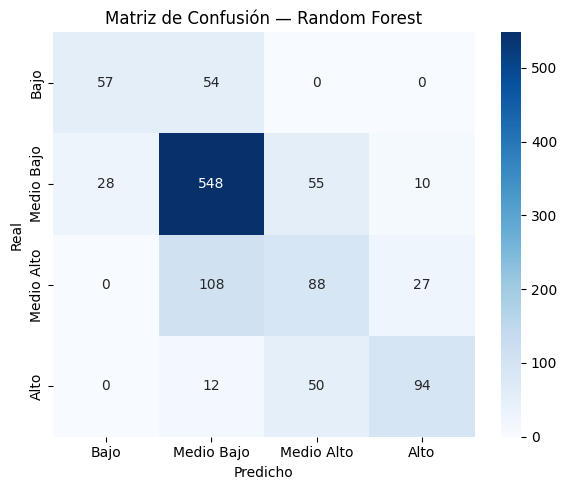

In [28]:
y_pred_rf = rf_search.predict(X_test)

print("=== Random Forest — Conjunto de prueba ===\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf,
                             target_names=['Bajo','Medio Bajo','Medio Alto','Alto']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bajo','Medio Bajo','Medio Alto','Alto'],
            yticklabels=['Bajo','Medio Bajo','Medio Alto','Alto'], ax=ax)
ax.set_title("Matriz de Confusión — Random Forest")
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

El modelo de Random Forest obtuvo un **accuracy de 0.6958** en el conjunto de prueba, siendo el mejor desempeño entre todos los modelos evaluados. La clase *Medio Bajo* (clase 2) es la que mejor predice el modelo, con un F1-score de 0.80, lo cual es esperable dado su predominio en el conjunto de datos (641 de 1 131 instancias de prueba). Las clases minoritarias como *Bajo* (111) y *Medio Alto* (223) obtienen F1-scores más bajos (0.58 y 0.42, respectivamente), lo que refleja el desbalance de clases. El F1-macro de 0.62 confirma que el desempeño es irregular entre clases.

### Boosting


=== AdaBoost (Boosting) — Conjunto de prueba ===

Accuracy: 0.6852

              precision    recall  f1-score   support

        Bajo       0.67      0.52      0.59       111
  Medio Bajo       0.75      0.85      0.80       641
  Medio Alto       0.43      0.39      0.41       223
        Alto       0.73      0.56      0.64       156

    accuracy                           0.69      1131
   macro avg       0.64      0.58      0.61      1131
weighted avg       0.68      0.69      0.68      1131



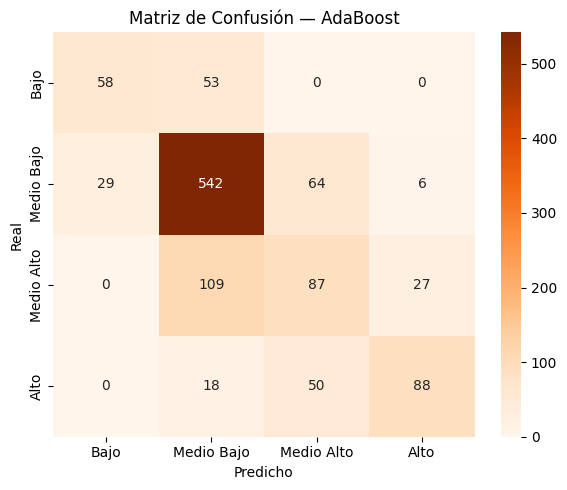

In [29]:
y_pred_babc = ada_search.predict(X_test)

print("=== AdaBoost (Boosting) — Conjunto de prueba ===\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_babc):.4f}\n")
print(classification_report(y_test, y_pred_babc,
                             target_names=['Bajo','Medio Bajo','Medio Alto','Alto']))

cm_babc = confusion_matrix(y_test, y_pred_babc)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_babc, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Bajo','Medio Bajo','Medio Alto','Alto'],
            yticklabels=['Bajo','Medio Bajo','Medio Alto','Alto'], ax=ax)
ax.set_title("Matriz de Confusión — AdaBoost")
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

AdaBoost obtuvo un **accuracy de 0.6852**, marginalmente inferior al de Random Forest (−1.1 puntos porcentuales). El patrón de errores es muy similar: la clase *Medio Bajo* es la mejor predicha (F1 = 0.80) y *Medio Alto* la más difícil (F1 = 0.41). El rendimiento comparable con Random Forest sugiere que ambos ensambles extraen información similar de los datos, aunque mediante mecanismos distintos (paralelo vs. secuencial). La ligera ventaja de Random Forest podría deberse a su mayor robustez frente al ruido y al desbalance de clases.

### Support Vector Machine (SVM)


=== SVM (RBF kernel) — Conjunto de prueba ===

Accuracy: 0.6012

              precision    recall  f1-score   support

        Bajo       0.48      0.91      0.63       111
  Medio Bajo       0.84      0.55      0.66       641
  Medio Alto       0.36      0.56      0.44       223
        Alto       0.65      0.67      0.66       156

    accuracy                           0.60      1131
   macro avg       0.58      0.67      0.60      1131
weighted avg       0.68      0.60      0.61      1131



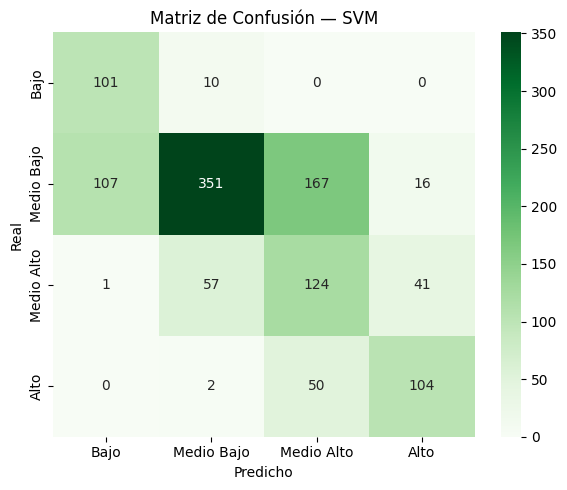

In [30]:
y_pred_svm = svm_search.predict(X_test)

print("=== SVM (RBF kernel) — Conjunto de prueba ===\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}\n")
print(classification_report(y_test, y_pred_svm,
                             target_names=['Bajo','Medio Bajo','Medio Alto','Alto']))

cm_svm = confusion_matrix(y_test, y_pred_svm)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bajo','Medio Bajo','Medio Alto','Alto'],
            yticklabels=['Bajo','Medio Bajo','Medio Alto','Alto'], ax=ax)
ax.set_title("Matriz de Confusión — SVM")
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

El SVM con kernel lineal y `class_weight='balanced'` obtuvo el **accuracy más bajo: 0.6012**, con una brecha de casi 10 puntos porcentuales respecto a Random Forest. Sin embargo, su F1-macro (0.60) es más cercano al de los ensambles que el accuracy sugiere, indicando que el modelo distribuye mejor sus predicciones entre clases. El balanceo de pesos (`class_weight='balanced'`) beneficia a las clases minoritarias: la clase *Bajo* alcanza un recall de 0.91, el más alto de todos los modelos, aunque a costa de una precisión baja (0.48). Este comportamiento es propio de modelos que priorizan no dejar sin clasificar a las clases pequeñas. El bajo rendimiento general del SVM en comparación con los ensambles puede atribuirse a que la frontera de decisión lineal no captura adecuadamente las interacciones no lineales presentes en los datos.

### Red Neuronal


=== Red Neuronal (MLP) — Conjunto de prueba ===

Accuracy: 0.6861

              precision    recall  f1-score   support

        Bajo       0.60      0.53      0.56       111
  Medio Bajo       0.76      0.83      0.79       641
  Medio Alto       0.46      0.33      0.38       223
        Alto       0.66      0.72      0.69       156

    accuracy                           0.69      1131
   macro avg       0.62      0.60      0.61      1131
weighted avg       0.67      0.69      0.67      1131



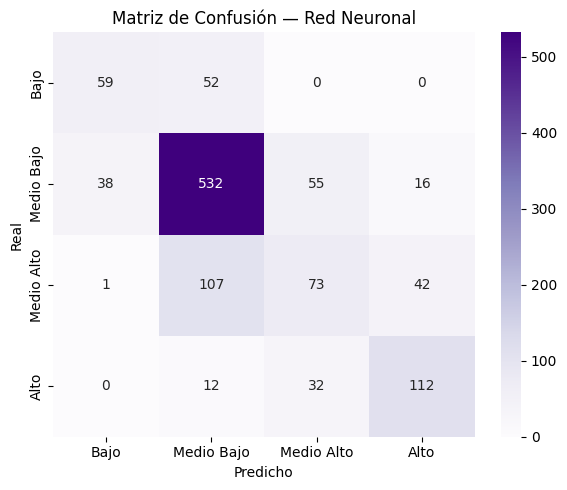

In [31]:
y_pred_nn = nn_search.predict(X_test)

print("=== Red Neuronal (MLP) — Conjunto de prueba ===\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nn):.4f}\n")
print(classification_report(y_test, y_pred_nn,
                             target_names=['Bajo','Medio Bajo','Medio Alto','Alto']))

cm_nn = confusion_matrix(y_test, y_pred_nn)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Bajo','Medio Bajo','Medio Alto','Alto'],
            yticklabels=['Bajo','Medio Bajo','Medio Alto','Alto'], ax=ax)
ax.set_title("Matriz de Confusión — Red Neuronal")
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

La red neuronal (MLP) obtuvo un **accuracy de 0.6861**, muy similar al de AdaBoost (diferencia de menos de 0.001). Su F1-macro (0.61) se ubica también entre los de los ensambles. La clase *Medio Bajo* sigue siendo la mejor predicha (F1 = 0.79), mientras que *Medio Alto* es la más difícil (F1 = 0.38). Comparado con Random Forest, la red neuronal muestra un desempeño ligeramente inferior en todas las métricas, lo que sugiere que una arquitectura de una sola capa con 128 neuronas no supera la capacidad predictiva del ensamble de árboles en este contexto. Esto podría mejorar con arquitecturas más profundas o con mayor ajuste de hiperparámetros.

### Tabla comparativa


=== Resumen comparativo — conjunto de prueba ===

               Accuracy  F1-macro  F1-weighted
Modelo                                        
Random Forest    0.6958    0.6160       0.6866
AdaBoost         0.6852    0.6067       0.6768
SVM              0.6012    0.5972       0.6141
Red Neuronal     0.6861    0.6061       0.6740


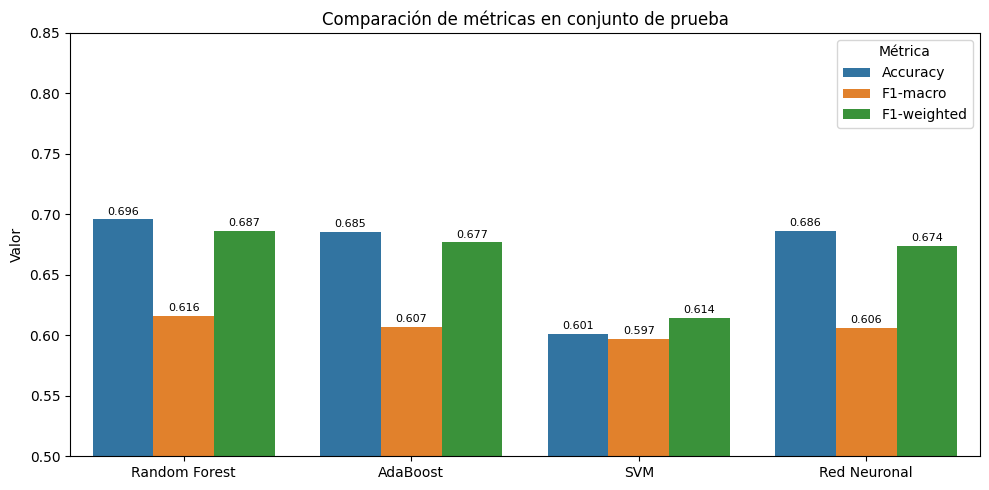

In [32]:
# ── Tabla comparativa de métricas en prueba ──────────────────────────────────

modelos = ['Random Forest', 'AdaBoost', 'SVM', 'Red Neuronal']
preds   = [y_pred_rf, y_pred_babc, y_pred_svm, y_pred_nn]

resultados = []
for nombre, y_pred in zip(modelos, preds):
    resultados.append({
        'Modelo'        : nombre,
        'Accuracy'      : round(accuracy_score(y_test, y_pred), 4),
        'F1-macro'      : round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1-weighted'   : round(f1_score(y_test, y_pred, average='weighted'), 4),
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print("=== Resumen comparativo — conjunto de prueba ===\n")
print(df_resultados.to_string())

# ── Gráfica comparativa ───────────────────────────────────────────────────────
df_plot = df_resultados.reset_index().melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_plot, x='Modelo', y='Valor', hue='Métrica', ax=ax)
ax.set_ylim(0.5, 0.85)
ax.set_title("Comparación de métricas en conjunto de prueba")
ax.set_ylabel("Valor")
ax.set_xlabel("")
ax.legend(title="Métrica")
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
plt.show()

---

## Análisis crítico

### ¿El aumento en complejidad se tradujo en mejoras claras?

En términos generales, la respuesta es **parcialmente sí**. Los modelos de ensamble (Random Forest y AdaBoost) superaron con claridad al SVM lineal y a la red neuronal de una sola capa. Sin embargo, la diferencia entre los propios ensambles fue marginal (menos de 1.1 puntos porcentuales en accuracy), lo que indica que la complejidad adicional de AdaBoost respecto a su variante de árbol único no generó mejoras significativas en este conjunto de datos.

El SVM, a pesar de ser un modelo teóricamente poderoso, obtuvo el peor accuracy (0.6012). Esto puede explicarse por dos razones: primero, el kernel lineal puede ser insuficiente si las fronteras de decisión reales son no lineales; segundo, las restricciones computacionales obligaron a limitar la búsqueda de hiperparámetros, lo que pudo dejar fuera configuraciones con mejor desempeño (e.g., kernel RBF con C ajustado). De igual forma, resultados experimentales concluyeron que realmente no había mejora en las métricas de validación usando el modelo con kernel RBF.

La red neuronal, con una sola capa oculta de 128 neuronas, no logró superar a los ensambles. Esto es consistente con la literatura: en conjuntos de datos de tamaño moderado y con variables categóricas/booleanas, los árboles de decisión y sus ensambles suelen competir muy bien con las redes neuronales poco profundas (Grinsztajn et al., 2022). 

### Riesgos de sobreajuste

Comparando las métricas de validación cruzada (CV) con las del conjunto de prueba, se aprecia una caída de desempeño en todos los modelos:

| Modelo | Accuracy CV | Accuracy Prueba | Diferencia |
|---|---|---|---|
| Random Forest | 0.7234 | 0.6958 | −0.028 |
| AdaBoost | 0.7204 | 0.6852 | −0.035 |
| SVM | 0.6415 | 0.6012 | −0.040 |
| Red Neuronal | 0.7094 | 0.6861 | −0.023 |

Estas caídas son moderadas y esperables. La red neuronal muestra la menor brecha (−0.023), lo que puede deberse al mecanismo de `early_stopping` que actúa como regularización implícita. AdaBoost presenta la mayor brecha (−0.035), lo que es coherente con la naturaleza del boosting: al ser un método secuencial que se enfoca en los errores del modelo anterior, tiende a ajustarse más a los datos de entrenamiento. Random Forest, gracias al bagging y la aleatoriedad en las características, presenta una caída intermedia.

### Interpretabilidad relativa

- **Random Forest**: Baja interpretabilidad directa (ensamble de cientos de árboles), aunque puede proporcionar importancia de variables como proxy. No es posible trazar un camino lógico desde las variables hasta la predicción.
- **AdaBoost**: Ligeramente más interpretable en teoría (suma ponderada de clasificadores débiles), pero en la práctica también resulta complejo de explicar a usuarios no técnicos, especialmente con 200 estimadores.
- **SVM**: Prácticamente ininterpretable a nivel de variables individuales; el hiperplano de separación no tiene un significado intuitivo claro en espacios de alta dimensión.
- **Red Neuronal**: La menos interpretable de todas. Las transformaciones no lineales en capas sucesivas dificultan cualquier explicación causal. Técnicas de XAI (SHAP, LIME) serían necesarias para una interpretación razonada.

### ¿Cuándo preferir cada modelo?

- **Random Forest**: Recomendado como modelo de referencia en producción. Ofrece el mejor desempeño, tolerancia al ruido y cierta capacidad de interpretación mediante importancias de variables. Ideal cuando se prioriza la exactitud y se puede aceptar cierta caja negra.
- **AdaBoost**: Alternativa válida si se requiere un modelo de ensamble secuencial con un rendimiento similar. Puede ser preferible si las clases están más balanceadas, ya que tiende a mejorar las observaciones difíciles de clasificar.
- **SVM**: Podría mejorar con un kernel RBF y mayor búsqueda de hiperparámetros. Es preferible en conjuntos de datos con pocas variables relevantes y fronteras de decisión claras. No es la mejor opción aquí dado el costo computacional y el rendimiento inferior.
- **Red Neuronal**: Podría superar a los ensambles con una arquitectura más profunda y más datos. Es la opción preferida cuando se dispone de grandes volúmenes de datos y se busca maximizar el desempeño a largo plazo.

---

## Conclusiones

Este análisis comparó cuatro modelos avanzados de clasificación —Random Forest, AdaBoost, SVM y Red Neuronal— para predecir el estrato socioeconómico de familias a partir de características de vivienda. Los principales hallazgos son:

1. **Random Forest obtuvo el mejor desempeño general** (accuracy = 0.6958, F1-weighted = 0.6866), seguido de cerca por AdaBoost (0.6852) y la Red Neuronal (0.6861). Las diferencias entre estos tres modelos son marginales (< 1.1 puntos porcentuales), lo que sugiere que, para este problema, el paradigma de ensamble o la arquitectura específica importan menos que la calidad de las características.

2. **El SVM lineal fue el peor modelo** (accuracy = 0.6012), posiblemente porque las fronteras de decisión en este espacio de características son no lineales, y la búsqueda de hiperparámetros fue restringida por razones computacionales.

3. **La clase *Medio Alto* (clase 3) fue consistentemente la más difícil de predecir** en todos los modelos (F1 entre 0.38 y 0.44). Esto puede deberse a que sus características de vivienda se solapan con las de las clases adyacentes, dificultando la discriminación.

4. **El aumento de complejidad no garantizó mejoras claras**. La red neuronal, teóricamente más flexible, no superó a los ensambles de árboles. Esto pone de manifiesto que la complejidad del modelo debe estar justificada por el tamaño y la estructura de los datos disponibles.

5. **El riesgo de sobreajuste es moderado y manejable** en todos los modelos, con brechas entre CV y prueba menores a 4 puntos porcentuales. La combinación de validación cruzada, regularización (alpha en MLP, profundidad máxima en árboles) y early stopping contribuyó a contener el sobreajuste.

6. **La interpretabilidad es un factor importante a considerar** en un contexto de política pública como la estratificación socioeconómica. Random Forest, aunque no totalmente transparente, ofrece la importancia de variables como herramienta de apoyo a la toma de decisiones, lo que lo convierte en el modelo más equilibrado entre desempeño e interpretabilidad para este caso de uso.

---

## Referencias

Ogunleye, B. (2024). An optimal house price prediction algorithm: XGBoost. Analytics, 3, 30–45. https://arxiv.org/pdf/2402.04082

Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). Why do tree-based models still outperform deep learning on tabular data? Advances in Neural Information Processing Systems (NeurIPS), 35. https://proceedings.neurips.cc/paper_files/paper/2022/file/0378c7692da36807bdec87ab043cdadc-Paper-Datasets_and_Benchmarks.pdf